# Data Exploration for Diabetes Risk Prediction

## Load Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("./data/diabetes_risk_prediction_dataset.csv")
df = df.drop(columns=['Patient_ID'])

## Analyze Data

### Numerical Data

In [4]:
# Select columns that contain numerical data
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols

['Age',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Waist_Circumference_cm',
 'Blood_Glucose',
 'HbA1c',
 'Fasting_Blood_Sugar',
 'Insulin_Level',
 'Blood_Pressure_Systolic',
 'Blood_Pressure_Diastolic',
 'Total_Cholesterol',
 'HDL',
 'LDL',
 'Triglycerides',
 'Heart_Rate',
 'Exercise_Hours_Per_Week',
 'Daily_Walking_Minutes',
 'Sleep_Hours',
 'Daily_Water_Intake_L',
 'Diabetes_Risk_Score']

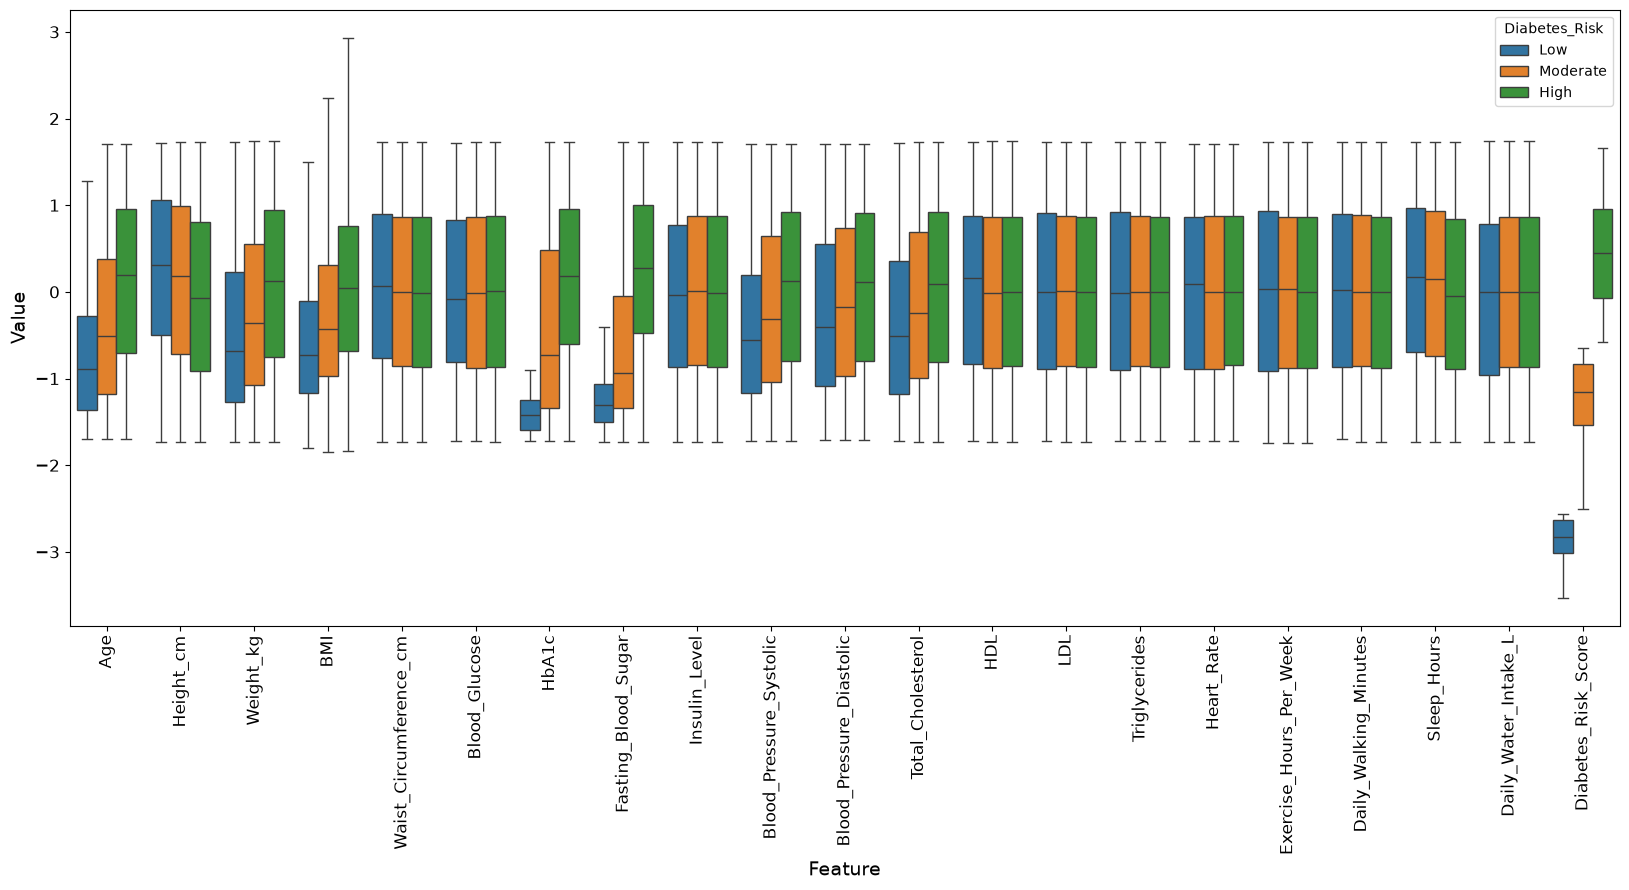

In [5]:
# Box plot to analyze distributions of numerical features based on low, moderate, or high diabetes risk

df[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
df_melted_num = df.melt(id_vars="Diabetes_Risk", value_vars=num_cols, var_name="Feature", value_name="Value")

plt.figure(figsize=(20, 8))

sns.boxplot(data=df_melted_num, x="Feature", y="Value", hue="Diabetes_Risk", hue_order=["Low", "Moderate", "High"], showfliers=False)

plt.xlabel("Feature", fontsize=14)
plt.ylabel("Value", fontsize=14)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Prioritize numerical features where there are __larger separations__ in distribution between __low__, __moderate__, and __high__ diabetes risk:
1. Age
1. Height_cm
1. Weight_kg
1. Blood_Glucose
1. HbA1c
1. Fasting_Blood_Sugar
1. Blood_Pressure_Systolic
1. Blood_Pressure_Diastolic
1. Total_Cholesterol
1. Sleep_Hours

In [6]:
num_cols = ["Age", "Height_cm", "Weight_kg", "Blood_Glucose", "HbA1c", "Fasting_Blood_Sugar", "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic", "Total_Cholesterol", "Sleep_Hours"]

### Categorical Data

In [7]:
# Select columns that contain string data
cat_cols = df.select_dtypes(include='str').columns.tolist()
cat_cols

['Gender',
 'Country',
 'Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption',
 'Family_History_Diabetes',
 'Hypertension',
 'Heart_Disease',
 'Fatty_Liver',
 'PCOS',
 'Medication_Adherence',
 'Work_Type',
 'Residence_Type',
 'AI_Health_Recommendation',
 'Doctor_Consultation_Needed',
 'Diabetes_Risk']

In [8]:
# Remove irrelevant columns

elements_to_remove = ["Gender", "Country", "Medication_Adherence", "Work_Type", "Residence_Type", "AI_Health_Recommendation", "Doctor_Consultation_Needed", "Diabetes_Risk"]

for element in elements_to_remove:
    if element in cat_cols:
        cat_cols.remove(element)
    
cat_cols

['Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption',
 'Family_History_Diabetes',
 'Hypertension',
 'Heart_Disease',
 'Fatty_Liver',
 'PCOS']

#### Categorical to Binary Data

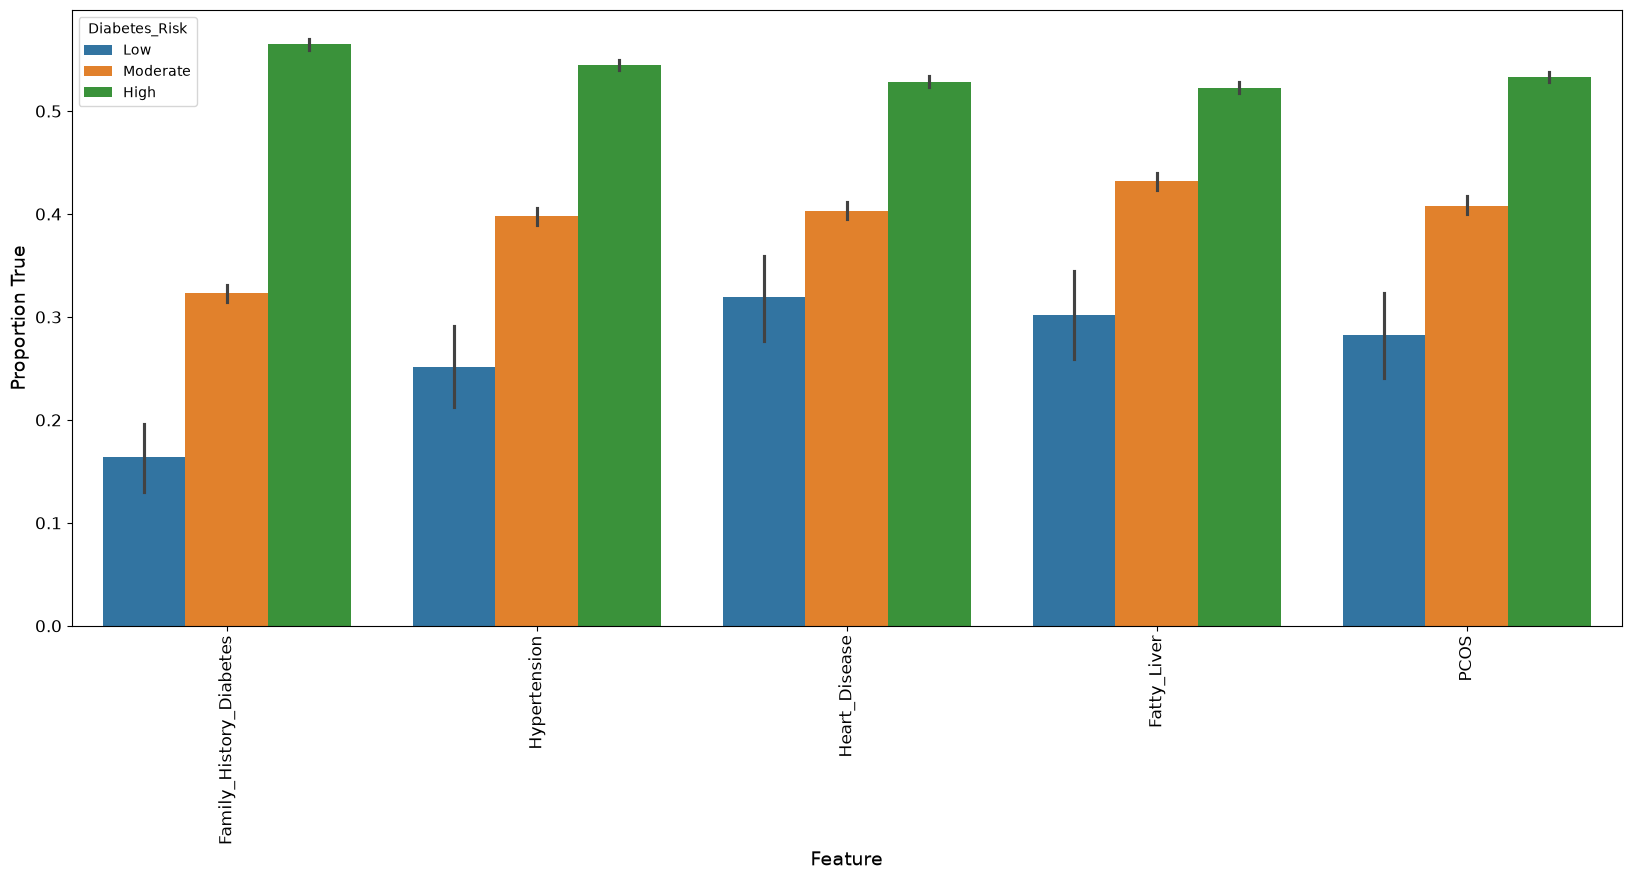

In [9]:
# Analyze string columns that can be converted to binary data

bin_cols = ['Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS']

df[bin_cols] = df[bin_cols].replace({"Yes": 1, "No": 0})

df_melted_bin = df.melt(id_vars="Diabetes_Risk", value_vars=bin_cols, var_name="Feature", value_name="Value")

# Bar plot shows percentage of patients who answer true to each of the features

plt.figure(figsize=(20, 8))

sns.barplot(data=df_melted_bin, x="Feature", y="Value", hue="Diabetes_Risk", hue_order=["Low", "Moderate", "High"], estimator="mean")

plt.xlabel("Feature", fontsize=14)
plt.ylabel("Proportion True", fontsize=14)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

All 5 binary categorical features show distinct separations between __low__, __moderate__, and __high__ diabetes risk:
1. Family_History_Diabetes
1. Hypertension
1. Heart_Disease
1. Fatty_Liver
1. PCOS

In [10]:
bin_cols = ["Family_History_Diabetes", "Hypertension", "Heart_Disease", "Fatty_Liver", "PCOS"]

In [11]:
cat_cols = [item for item in cat_cols if item not in bin_cols]
cat_cols

['Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption']

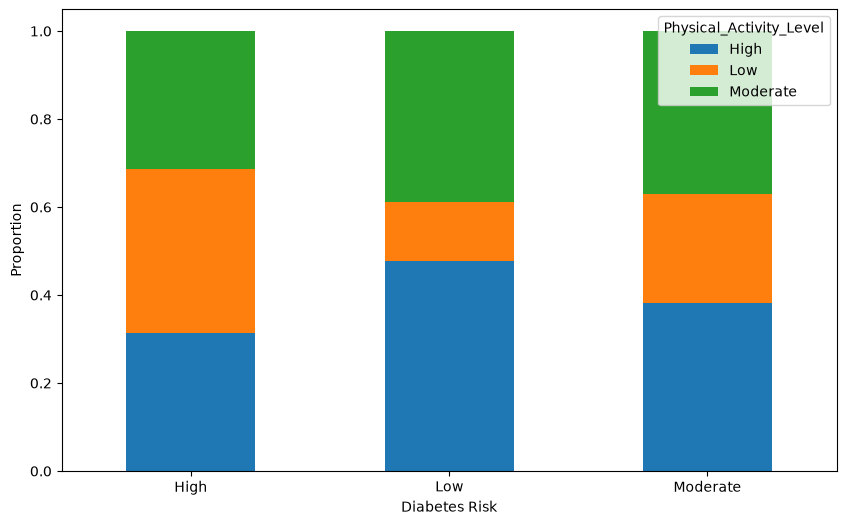

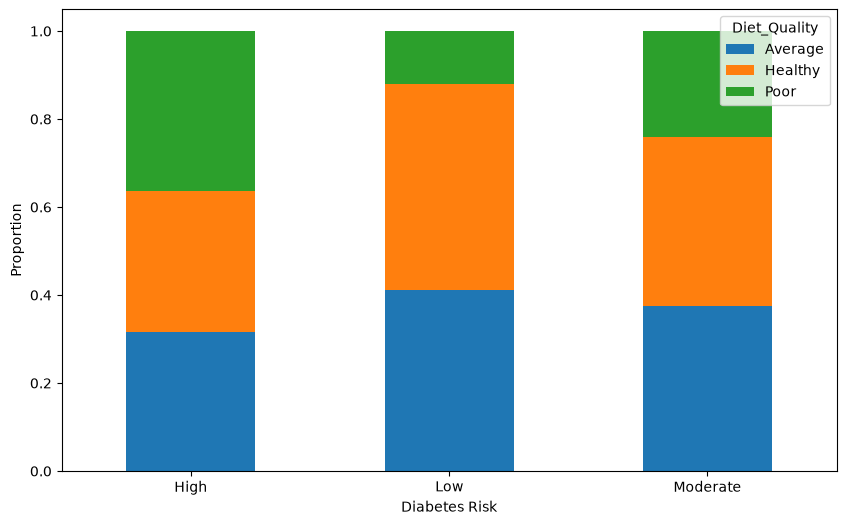

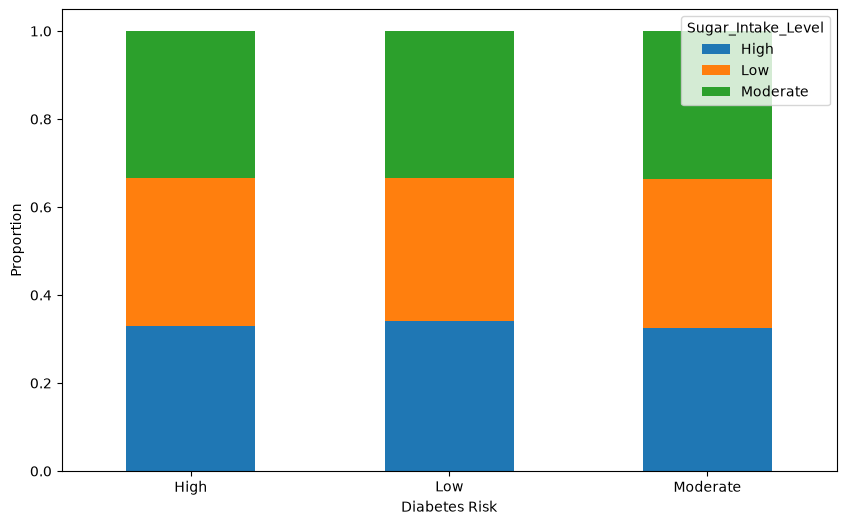

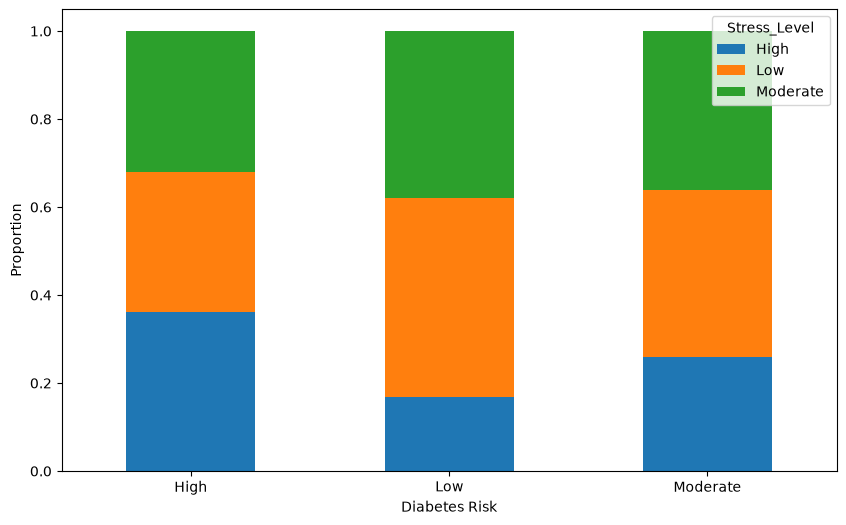

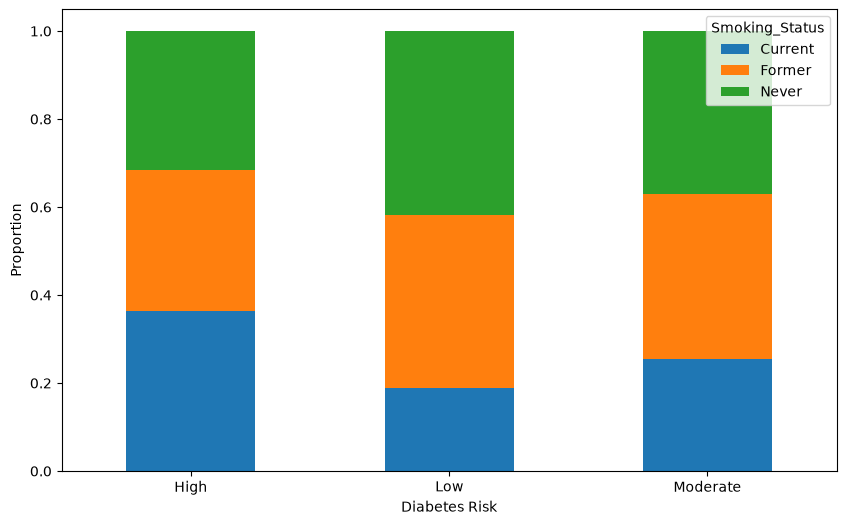

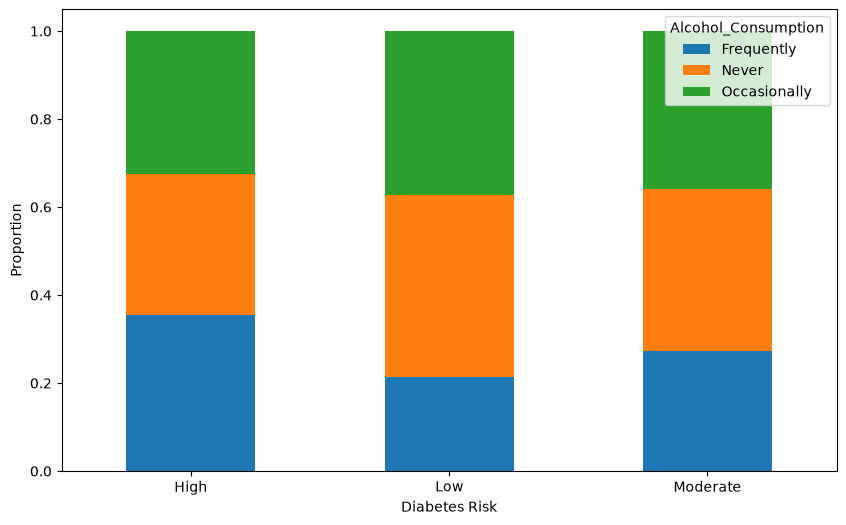

In [12]:
for col in cat_cols:
    pd.crosstab(
        df["Diabetes_Risk"],
        df[col],
        normalize="index"
    ).plot(kind="bar", stacked=True, figsize=(10,6))
    
    plt.ylabel("Proportion")
    plt.xlabel("Diabetes Risk")
    plt.xticks(rotation=0)
    plt.legend(title=col)
    plt.show()

5 of the 6 categorical columns show correlations between the category and diabetes risk:
1. Physical_Activity_Level
1. Diet_Quality
1. Stress_Level
1. Smoking_Status
1. Alcohol_Consumption


In [13]:
cat_cols = ["Physical_Activity_Level", "Diet_Quality", "Stress_Level", "Smoking_Status", "Alcohol_Consumption"]

## Takeaways

### Final Columns List

The columns which can be help as predictors for diabetes risk:
1. Age (Numerical)
1. Height_cm (Numerical)
1. Weight_kg (Numerical)
1. Blood_Glucose (Numerical)
1. HbA1c (Numerical)
1. Fasting_Blood_Sugar (Numerical)
1. Blood_Pressure_Systolic (Numerical)
1. Blood_Pressure_Diastolic (Numerical)
1. Total_Cholesterol (Numerical)
1. Sleep_Hours (Numerical)
1. Family_History_Diabetes (Binary)
1. Hypertension (Binary)
1. Heart_Disease (Binary)
1. Fatty_Liver (Binary)
1. PCOS (Binary)
1. Physical_Activity_Level (3 Categories)
1. Diet_Quality (3 Categories)
1. Stress_Level (3 Categories)
1. Smoking_Status (3 Categories)
1. Alcohol_Consumption (3 Categories)

Once multi-categorical columns are one-hot encoded, this translates to __30 inputs__.

In [14]:
cols = num_cols + bin_cols + cat_cols + ["Diabetes_Risk"]

df = df[cols]

In [15]:
df = pd.get_dummies(df, columns=cat_cols, dtype=int)

In [16]:
df.head()

,Age,Height_cm,Weight_kg,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,Sleep_Hours,...,Diet_Quality_Poor,Stress_Level_High,Stress_Level_Low,Stress_Level_Moderate,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Alcohol_Consumption_Frequently,Alcohol_Consumption_Never,Alcohol_Consumption_Occasionally
0,-1.035066,0.835618,-0.883946,-1.374029,0.826335,0.154262,-1.582904,-1.652243,-1.409647,0.689954,...,0,0,0,1,0,1,0,0,1,0
1,-0.561809,-1.488389,0.560930,1.679358,1.215313,1.268810,0.268401,0.566755,1.152919,-0.148396,...,0,0,0,1,1,0,0,1,0,0
2,1.662501,-0.824387,NaN,-0.345985,-0.945674,1.723134,-1.342920,1.021934,-1.570565,-0.838802,...,0,1,0,0,0,0,1,1,0,0
3,1.567850,1.444286,0.344607,-1.341362,-0.470257,1.680611,-0.691535,-1.538448,-0.899210,-1.134690,...,0,1,0,0,1,0,0,0,0,1
4,-1.271695,-0.907387,0.589501,-1.270264,1.517851,0.243784,1.708304,-0.002219,1.061213,1.676248,...,1,0,1,0,0,0,1,0,0,1
